# Application of WAVEGUISE to a vertical wind BAHAMAS time series

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parents[1] / "scripts"))
sys.path.append(str(Path.cwd().parents[2] / "juwavelet"))
import juwavelet.transform as transform
from juwavelet import utils
import waveguise_1d as one

import copy
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [2]:
filename = str(Path.cwd().parents[1] / "data/time_vertical_wind_10Hz.dat")

data = np.loadtxt(filename)
time = data[:, 0]   # Zeit in Sekunden
wind = data[:, 1]   # Wind in m/s

In [3]:
# Background Removal with polynomial degree 1 and Fourier coefficients up to 1.
dt, nt        = 0.1, len(wind) #[s]
time          = np.linspace(dt,nt*dt,nt)
orig          = wind.copy()
w_high, w_low = one.BG_removal(orig,max_order=1)

# The outer 10% of the data are tapered.
nmask  = orig.shape
ntap   = int(0.1*np.min(nmask))
signal = utils.smooth_edges(w_high, ntap, window='tukey')

# Define parameters for the CWT.
s0 = 2 #smallest scale that we wanna resolve
s1 = 0.5 * nt #largest scale is about half the domain size
dj = 1/8
js = int(1/dj*np.log2(s1/s0))
cwt_result = transform.decompose1d(signal, dt, s0 * dt, dj, js, opts={'param': 2*np.pi}, mode="scaled", dtype=np.complex128)

# Denoising
noise_level = 0.4
wavy_stuff, denoised_cwt = one.denoise_1d(cwt_result,white_noise_level=4*noise_level) #the empirical factor of ~4 results in sufficient noise reduction

params = {
    "Data size": f"{signal.size:.0f}",
    "Smallest scale (s0)": f"{s0:.0f}",
    "Largest scale (s1)": f"{s1:.0f}",
    "Scale sampling (dj)": f"{dj:.3f}",
    "Number of scales (js)": f"{js:.0f}",
    "Non-dimensional frequency": f"{cwt_result['opts']['param']:.2f}",
    "Noise level": f"{noise_level:.1f}",
}
label_width = max(len(label) for label in params)
for label, value in params.items():
    print(f"{label:<{label_width}} : {value}")

Data size                 : 12000
Smallest scale (s0)       : 2
Largest scale (s1)        : 6000
Scale sampling (dj)       : 0.125
Number of scales (js)     : 92
Non-dimensional frequency : 6.28
Noise level               : 0.4


Text(0.03, 0.94, 'c')

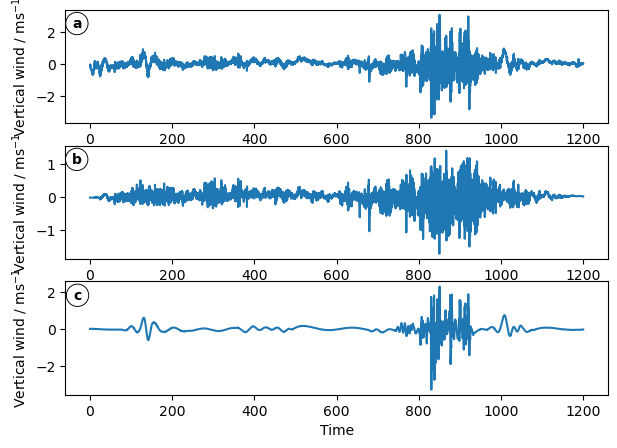

In [4]:
fig=plt.figure(figsize=(7,5))
ax1 = fig.add_subplot(311)
ax1.plot(time,wind)
ax2 = fig.add_subplot(312)
ax2.plot(time,w_low+signal-wavy_stuff+np.mean(wind))
ax3 = fig.add_subplot(313)
ax3.plot(time,wavy_stuff)

ax1.set_ylabel('Vertical wind / ms$^{-1}$')
ax2.set_ylabel('Vertical wind / ms$^{-1}$')
ax3.set_ylabel('Vertical wind / ms$^{-1}$')
ax3.set_xlabel('Time')

letterbox = {"boxstyle": "circle","lw": 0.67,"facecolor": "white","edgecolor": "black"}
ax1.text(0.03,0.94,'a',transform=ax1.transAxes, bbox=letterbox, verticalalignment="top", horizontalalignment="right", weight="bold") 
ax2.text(0.03,0.94,'b',transform=ax2.transAxes, bbox=letterbox, verticalalignment="top", horizontalalignment="right", weight="bold") 
ax3.text(0.03,0.94,'c',transform=ax3.transAxes, bbox=letterbox, verticalalignment="top", horizontalalignment="right", weight="bold") 

In [7]:
WAS        = np.abs(denoised_cwt['decomposition'])
seg_v1     = one.wavefield_segmentation_1d(WAS,0.1*noise_level,connectivity_order=1)
print('Identified', np.max(seg_v1), 'initial wave packets!')
WP_labels      = np.arange(1,np.max(seg_v1)+1)
k     = 2*np.pi/cwt_result['period']
eps   = 1.01*np.abs(np.diff(np.log(k)))[0]
cluster_labels = one.find_clusters_in_freq(denoised_cwt, seg_v1, eps=eps)
cluster_map    = one.build_cluster_map_with_noise(WP_labels,cluster_labels)
seg_v2         = one.relabel_by_x_overlap(seg_v1, cluster_map)
print('Reduced the number of wave packets to', np.max(seg_v2))
seg_v3         = one.variance_filter(denoised_cwt, seg_v2, var_threshold=0.99)
print('Final number of wave packets:', np.max(seg_v3))

Identified 38 initial wave packets!
Reduced the number of wave packets to 34
Final number of wave packets: 26


In [8]:
recon_seg, amp_seg, freq_seg = one.recon_WP_and_properties_1d(denoised_cwt,seg_v3)

In [9]:
def get_distinct_colors(n, saturation=0.75, value=0.9):
    hues = np.linspace(0, 1, n, endpoint=False)
    colors = [mcolors.hsv_to_rgb((h, saturation, value)) for h in hues]
    return colors

def darken(color, factor=0.8):
    rgb = mcolors.to_rgb(color)
    return tuple(factor * c for c in rgb)

def compute_offsets(wavy_stuff, amp_seg):
    base = -np.max(np.abs(wavy_stuff))
    offsets = []
    cumulative = 0.0

    for seg in amp_seg:
        current = base - cumulative - 2*np.max(seg)
        offsets.append(current)
        cumulative += 2*np.max(seg)

    return np.array(offsets)

/scratch-local/slurm-job-tmp-14985722/ipykernel_2059/3006674629.py:1: RuntimeWarning: divide by zero encountered in divide
  per_seg = 2*np.pi/freq_seg


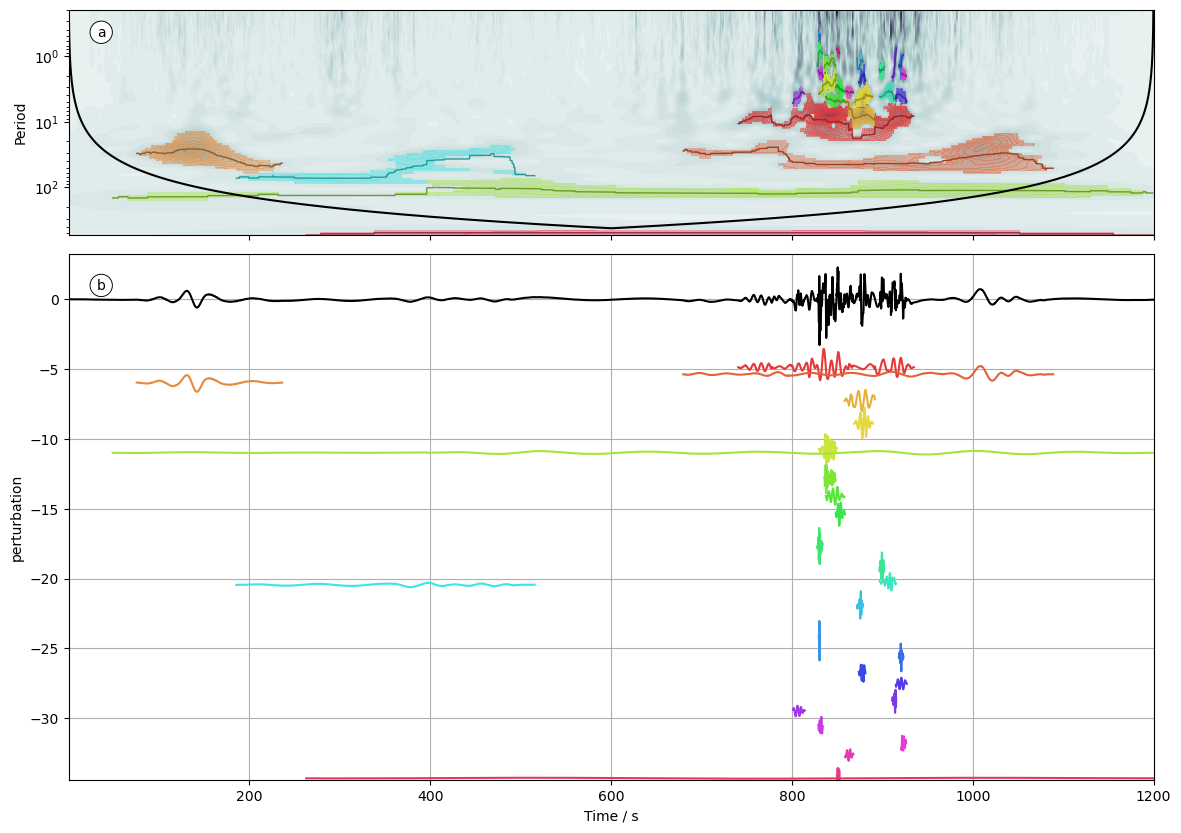

In [10]:
per_seg = 2*np.pi/freq_seg
WAS = np.abs(cwt_result['decomposition'])

N_waves = np.max(seg_v3)
colors  = get_distinct_colors(N_waves)

TIME, PERIOD = np.meshgrid(time, cwt_result["period"])

letterbox = {"boxstyle": "circle","lw": 0.67,"facecolor": "white","edgecolor": "black"}
gskw = {"hspace": 0.05, "wspace": 0.05, "width_ratios": [1], "height_ratios": [3,7]}

fig, ax=plt.subplots(2, 1, figsize=(14,10), gridspec_kw=gskw, sharex=True)

plot_WAS = ax[0].contourf(TIME, PERIOD, WAS, levels=np.linspace(-0.1,np.max(WAS),51), cmap='bone_r')
ax[0].set_yscale("log")
ax[0].set_ylabel("Period")
ax[0].set_ylim([np.max(cwt_result['period']),np.min(cwt_result['period'])])

ax[1].tick_params(which="both", labelbottom=True, labeltop=False)
ax[1].set_xlabel('Time / s')

for lab in np.unique(seg_v3):
    if lab == 0:
        continue
    mask     = (seg_v3 == lab)
    if not np.any(mask):
        continue

    # Create a noise WAS as proper reference
    noise = np.random.normal(0,noise_level,len(time))
    noise_cwt = transform.decompose1d(noise, dt, s0, dj, js, opts={'param': 2*np.pi}, mode='scaled', dtype=np.complex128)
    noise_WAS = one.get_noise_WAS(noise_cwt['scale'],np.mean(np.abs(noise_cwt['decomposition']),axis=1))

    mask = (seg_v3 == lab) & (WAS > noise_WAS[:,None])
    masked_WAS = np.ma.masked_where(~mask, WAS)
    # Base color
    base = mcolors.to_rgb(colors[lab-1])
    
    # Create custom colormap: white -> orange -> black
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "white_orange_black",
        [(0.0, base),(0.5, base),(1.0, base)]
    )
    ax[0].contourf(TIME, PERIOD, masked_WAS, levels=np.linspace(0,np.max(WAS),51), cmap=cmap, alpha=0.4)
    ax[0].plot(time, per_seg[lab-1,:], c=darken(colors[lab-1],factor=0.67), linewidth=1)

x2 = time
order=2*np.pi
coi_x = np.minimum(x2,x2[-1]-x2)
coi_boundary_scale = coi_x / np.sqrt(2)
coi_boundary_wavelength = 4*np.pi*coi_boundary_scale/(order+np.sqrt(2+order**2))
ax[0].plot(time, coi_boundary_wavelength, c='k')

offset = compute_offsets(wavy_stuff,amp_seg)

# ORIGINAL
ax[1].plot(time, wavy_stuff, c='k', label='original')
ax[1].set_ylabel('perturbation')
ax[1].set_ylim([2*offset[-1]-offset[-2],np.max(np.abs(wavy_stuff))])

for idx in range(N_waves):
    ax[1].plot(time,np.where(amp_seg[idx]==0,np.nan,recon_seg[idx]+offset[idx]),c=colors[idx])

ax[0].text(0.03,0.9,'a',va='center', ha='center', bbox=letterbox, transform=ax[0].transAxes)
ax[1].text(0.03,0.94,'b',va='center', ha='center', bbox=letterbox, transform=ax[1].transAxes)
ax[1].grid(which='both')